# Notebook 2 — Exploratory Data Analysis (EDA)

Visual analysis of attrition patterns across demographics, departments, satisfaction scores, and income.

## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

## Load Cleaned Data

In [2]:
df = pd.read_csv('df_raw_clean.csv')
print('Loaded:', df.shape)

Loaded: (1470, 35)


## 4. Exploratory Data Analysis (EDA)

We look at:
- Overall attrition rate
- Attrition by department, overtime, job satisfaction, and work-life balance
- Distributions of key numeric drivers (age, monthly income, years at company)
- A correlation heatmap of numeric features

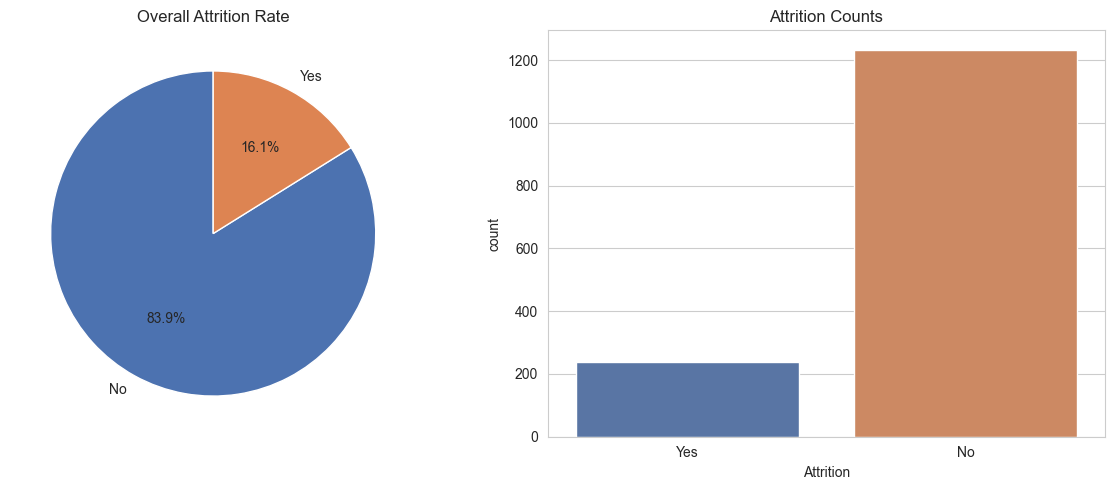

In [3]:
# Overall attrition rate
attrition_counts = df['Attrition'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
          colors=['#4C72B0', '#DD8452'], startangle=90)
ax[0].set_title('Overall Attrition Rate')

sns.countplot(data=df, x='Attrition', ax=ax[1], palette=['#4C72B0', '#DD8452'])
ax[1].set_title('Attrition Counts')
plt.tight_layout()
plt.show()


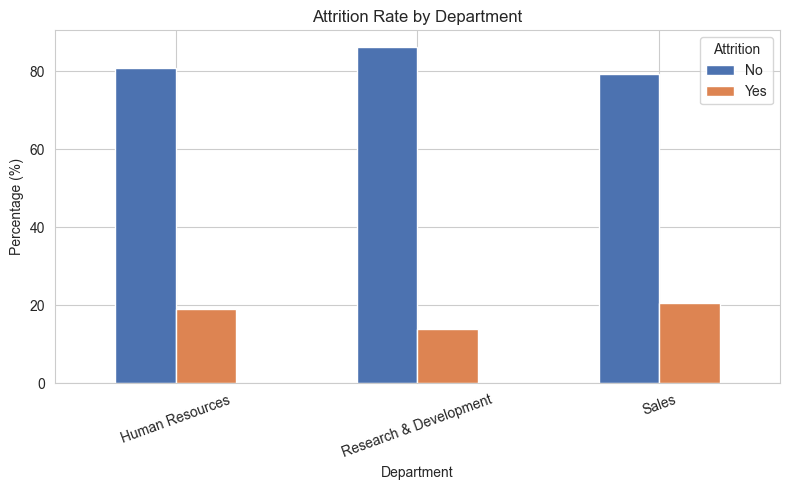

In [4]:
# Attrition by Department
fig, ax = plt.subplots(figsize=(8, 5))
dept_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
dept_attrition.plot(kind='bar', stacked=False, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Attrition Rate by Department')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


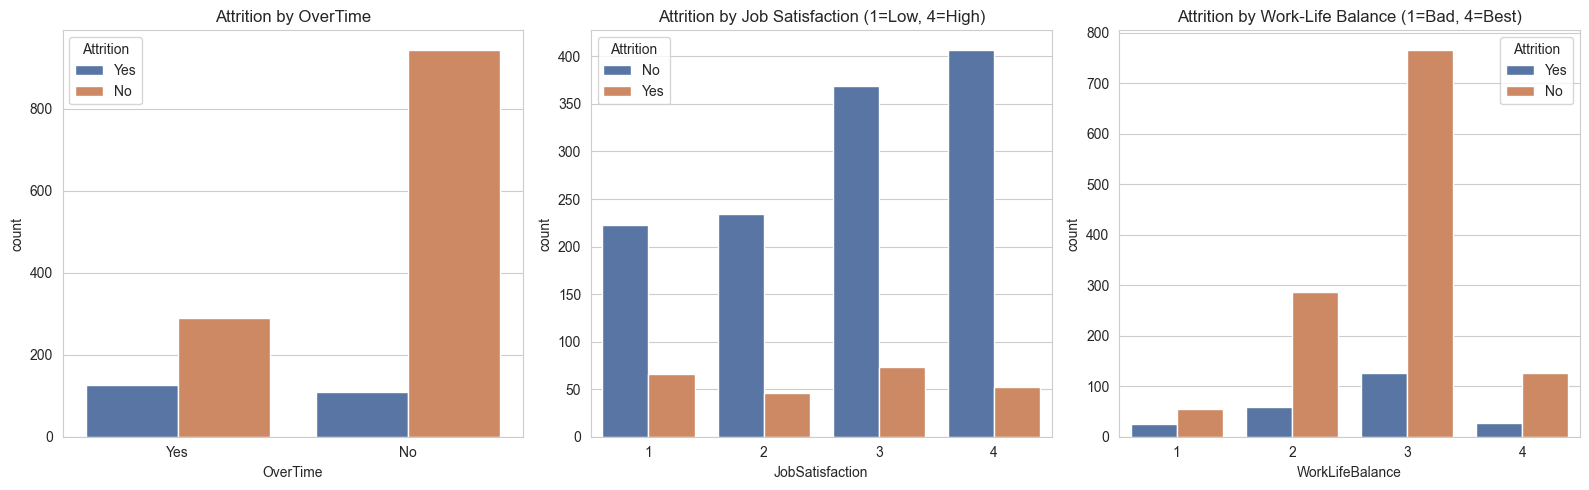

In [5]:
# Attrition by OverTime, JobSatisfaction, WorkLifeBalance
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Attrition by OverTime')

sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Attrition by Job Satisfaction (1=Low, 4=High)')

sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition', ax=axes[2], palette=['#4C72B0', '#DD8452'])
axes[2].set_title('Attrition by Work-Life Balance (1=Bad, 4=Best)')

plt.tight_layout()
plt.show()


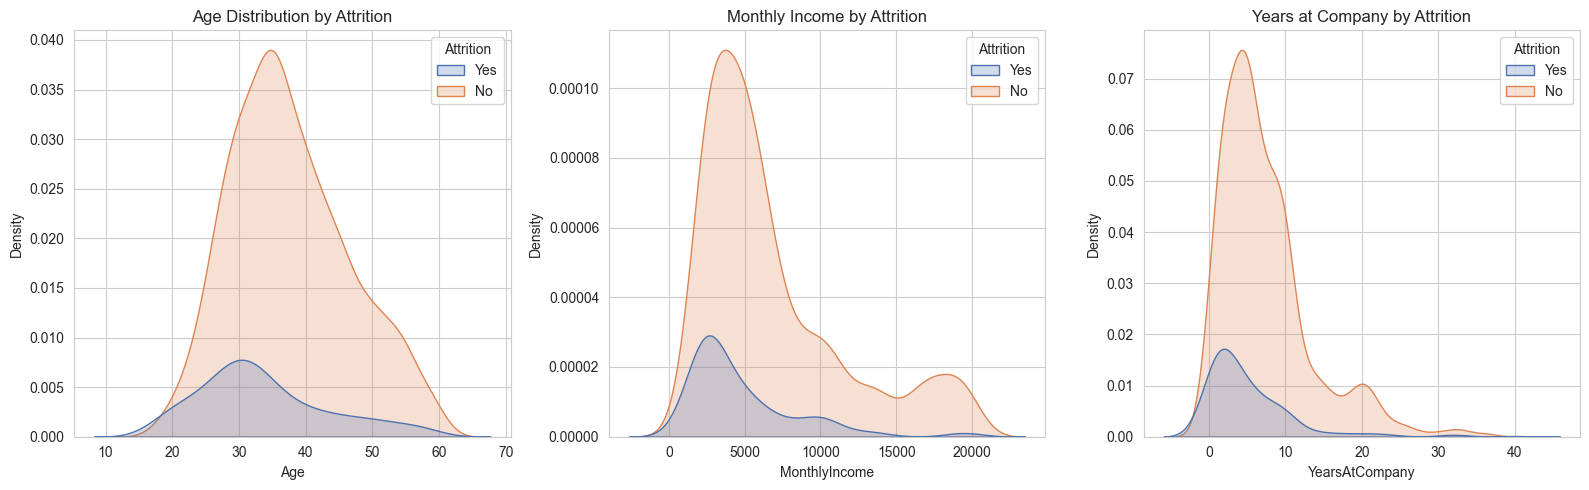

In [6]:
# Distributions: Age, Monthly Income, Years at Company by Attrition
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Age Distribution by Attrition')

sns.kdeplot(data=df, x='MonthlyIncome', hue='Attrition', fill=True, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Monthly Income by Attrition')

sns.kdeplot(data=df, x='YearsAtCompany', hue='Attrition', fill=True, ax=axes[2], palette=['#4C72B0', '#DD8452'])
axes[2].set_title('Years at Company by Attrition')

plt.tight_layout()
plt.show()


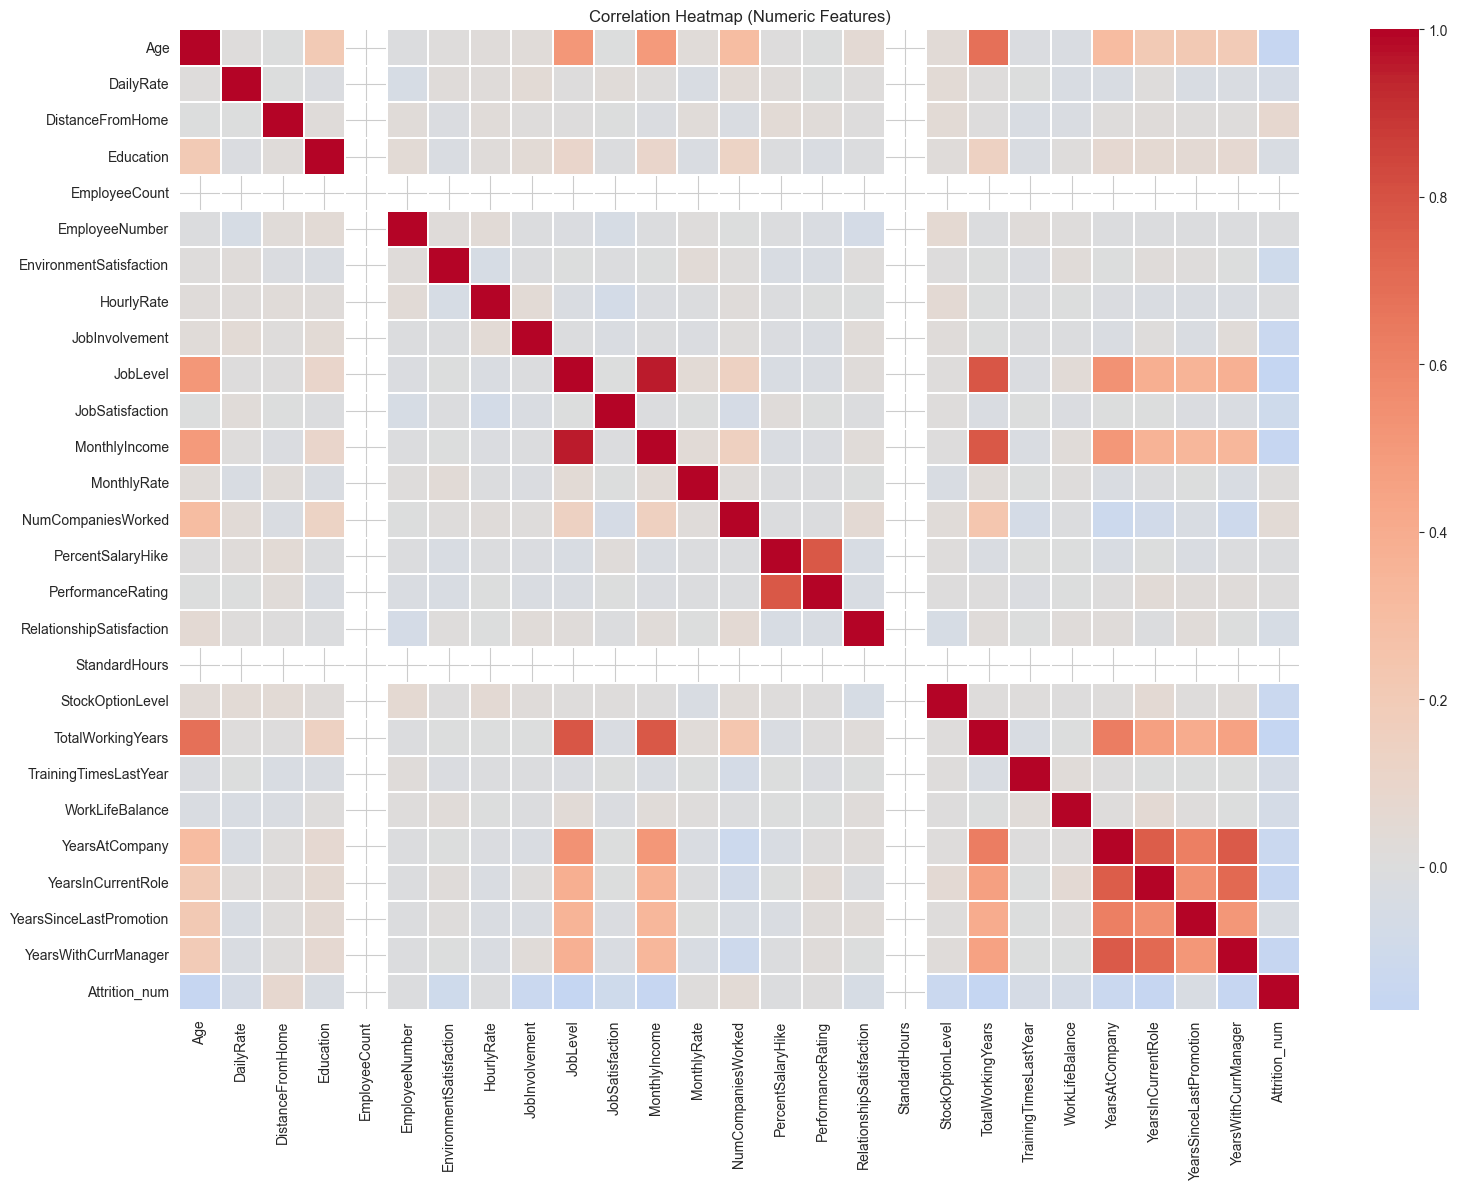

In [7]:
# Correlation heatmap of numeric features (with target encoded numerically)
df_corr = df.copy()
df_corr['Attrition_num'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})
numeric_for_corr = df_corr.select_dtypes(include=np.number)

plt.figure(figsize=(16, 12))
corr = numeric_for_corr.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


In [8]:
# Features most correlated with Attrition (numeric only)
target_corr = corr['Attrition_num'].drop('Attrition_num').sort_values(key=abs, ascending=False)
print("Top 10 numeric features correlated with Attrition:")
print(target_corr.head(10))


Top 10 numeric features correlated with Attrition:
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481
Name: Attrition_num, dtype: float64
